In [1]:
##### Correlation between capital and labor intensity, and bivariate classification
# Country-scale + pixel-scale correlation, scatterplots, and 3x3 LMH classification map

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from rasterio.features import rasterize
from matplotlib.colors import to_hex

In [4]:
##### Load data

cd = os.path.dirname(os.getcwd())

# pixel intensities 
capital_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/capital_intensity_USD_per_tonne.tif")
labor_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/labor_intensity_jobs_per_tonne.tif")

# sub-national intensities 
sub_national_capital = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_capital_intensity.csv")
sub_national_labor = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_labor_intensity.csv")
sub_national_capital_geo = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_capital.shp")
sub_national_labor_geo = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_labor.shp")

# country intensities
country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

has_data = pd.read_csv(f'{cd}/Data/Correspondence_tables/has_data.csv')

# set figure directory
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/correlation_capital_labor"

In [5]:
##### Data prep

# align CRS
target_crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
capital_intensity = capital_intensity.rio.reproject(target_crs)

labor_intensity = labor_intensity.rio.reproject_match(capital_intensity)

sub_national_capital_geo = sub_national_capital_geo.to_crs(capital_intensity.rio.crs)
sub_national_labor_geo = sub_national_labor_geo.to_crs(capital_intensity.rio.crs)
country_boundaries = country_boundaries.to_crs(capital_intensity.rio.crs)

crs = capital_intensity.rio.crs

# merge sub-national data
sub_national_capital = sub_national_capital_geo.merge(sub_national_capital, on='PROJ_ID', how='left')
sub_national_labor = sub_national_labor_geo.merge(sub_national_labor, on='PROJ_ID', how='left')
sub_national = sub_national_capital.merge(sub_national_labor, on=['PROJ_ID', 'ISO3', 'geometry'], how='inner')
sub_national = sub_national.merge(country_codes, on='ISO3', how='left') # add income group data

# merge country-level data
country_boundaries = country_boundaries.merge(country_intensities, on='ISO3', how='left')

In [6]:
##### Identify no data countries 

country_boundaries = country_boundaries.merge(has_data, on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)
country_boundaries['has_capital_and_labor_data'] = (
    (country_boundaries['has_capital_data'] == 1) &
    (country_boundaries['has_labor_data'] == 1)
).astype(int)

In [7]:
##### Convert intensities to log1p 

# first convert units so log1p doesn't distort to much 
capital_intensity_per_million_tonne = capital_intensity * 1e6
sub_national['capital_intensity_USD_per_million_tonne'] = sub_national['capital_intensity_USD_per_tonne'] * 1e6
country_boundaries['capital_intensity_USD_per_million_tonne'] = country_boundaries['capital_intensity_USD_per_tonne'] * 1e6

labor_intensity_per_million_tonne = labor_intensity * 1e6
sub_national['labor_intensity_jobs_per_million_tonne'] = sub_national['labor_intensity_jobs_per_tonne'] * 1e6
country_boundaries['labor_intensity_jobs_per_million_tonne'] = country_boundaries['labor_intensity_jobs_per_tonne'] * 1e6

# convert to log1p (so don't have to drop 0's)
log1p_capital_intensity_per_million_tonne = np.log1p(capital_intensity_per_million_tonne)
sub_national['log1p_capital_intensity_USD_per_million_tonne'] = np.log1p(sub_national['capital_intensity_USD_per_million_tonne'])
country_boundaries['log1p_capital_intensity_USD_per_million_tonne'] = np.log1p(country_boundaries['capital_intensity_USD_per_million_tonne'])

log1p_labor_intensity_per_million_tonne = np.log1p(labor_intensity_per_million_tonne)
sub_national['log1p_labor_intensity_jobs_per_million_tonne'] = np.log1p(sub_national['labor_intensity_jobs_per_million_tonne'])
country_boundaries['log1p_labor_intensity_jobs_per_million_tonne'] = np.log1p(country_boundaries['labor_intensity_jobs_per_million_tonne'])

In [10]:
##### Rasterize income group data

# numeric code for each income group 
income_groups = sorted(country_boundaries['income_gro'].dropna().unique())
income_code_map = {group: i for i, group in enumerate(income_groups)}
country_boundaries['income_code'] = country_boundaries['income_gro'].map(income_code_map)

shapes = [
    (geom, code)
    for geom, code in zip(country_boundaries.geometry, country_boundaries['income_code'])
    if pd.notna(code)
]

template = capital_intensity.squeeze()

income_raster = rasterize(
    shapes=shapes,
    out_shape=template.shape,
    transform=template.rio.transform(),
    fill=-1,          # code for "no country / no income data"
    dtype="int16"
)

/Users/carinamanitius/Library/Python/3.9/lib/python/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape None at index 3 will not be rasterized.
  warnings.warn(
/Users/carinamanitius/Library/Python/3.9/lib/python/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape None at index 69 will not be rasterized.
  warnings.warn(
/Users/carinamanitius/Library/Python/3.9/lib/python/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape None at index 70 will not be rasterized.
  warnings.warn(
/Users/carinamanitius/Library/Python/3.9/lib/python/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape None at index 71 will not be rasterized.
  warnings.warn(
/Users/carinamanitius/Library/Python/3.9/lib/python/site-packages/rasterio/features.py:336: ShapeSkipWarning: Invalid or empty shape None at index 72 will not be rasterized.
  warnings.warn(
/Users/carinamanitius/Library/Python/3.9/lib/p

#### Calculate correlations

In [11]:
##### Correlation: country scale (log intensities)

# mask so both capital and labor have intensities 
country_valid = country_boundaries[
    country_boundaries['log1p_capital_intensity_USD_per_million_tonne'].notna() &
    country_boundaries['log1p_labor_intensity_jobs_per_million_tonne'].notna() 
]

# get values
x_country = country_valid['log1p_capital_intensity_USD_per_million_tonne'].values
y_country = country_valid['log1p_labor_intensity_jobs_per_million_tonne'].values

# calculate stats
pearson_country = stats.pearsonr(x_country, y_country)
spearman_country = stats.spearmanr(x_country, y_country)

print("Country-scale correlation (log1p-log1p):")
print(f"  Pearson r = {pearson_country[0]:.3f}, p = {pearson_country[1]:.3g}, n = {len(x_country)}")
print(f"  Spearman rho = {spearman_country[0]:.3f}, p = {spearman_country[1]:.3g}")

Country-scale correlation (log1p-log1p):
  Pearson r = -0.337, p = 2.51e-06, n = 186
  Spearman rho = -0.361, p = 4.28e-07


In [12]:
##### Correlation: sub-national scale (log intensities)

# mask so both capital and labor have intensities 
sub_valid = sub_national[
    sub_national['log1p_capital_intensity_USD_per_million_tonne'].notna() &
    sub_national['log1p_labor_intensity_jobs_per_million_tonne'].notna() 
]

# get values
x_sub = sub_valid['log1p_capital_intensity_USD_per_million_tonne'].values
y_sub = sub_valid['log1p_labor_intensity_jobs_per_million_tonne'].values

# calculate stats
pearson_sub = stats.pearsonr(x_sub, y_sub)
spearman_sub = stats.spearmanr(x_sub, y_sub)

print("Sub-national-scale correlation (log1p-log1p):")
print(f"  Pearson r = {pearson_sub[0]:.3f}, p = {pearson_sub[1]:.3g}, n = {len(x_sub)}")
print(f"  Spearman rho = {spearman_sub[0]:.3f}, p = {spearman_sub[1]:.3g}")

Sub-national-scale correlation (log1p-log1p):
  Pearson r = 0.382, p = 0, n = 10183
  Spearman rho = 0.361, p = 0


In [13]:
##### Correlation: pixel scale (log intensities)

cap_vals = log1p_capital_intensity_per_million_tonne.squeeze().values.flatten()
lab_vals = log1p_labor_intensity_per_million_tonne.squeeze().values.flatten()

# mask so both capital and labor have intensities 
finite_mask = np.isfinite(cap_vals) & np.isfinite(lab_vals)
valid_mask = (finite_mask)

# get values
x_pixel = cap_vals[valid_mask]
y_pixel = lab_vals[valid_mask]

# calculate stats
pearson_pixel = stats.pearsonr(x_pixel, y_pixel)
spearman_pixel = stats.spearmanr(x_pixel, y_pixel)

print("\nPixel-scale correlation (log1p-log1p):")
print(f"  Pearson r = {pearson_pixel[0]:.3f}, p = {pearson_pixel[1]:.3g}, n = {len(x_pixel)}")
print(f"  Spearman rho = {spearman_pixel[0]:.3f}, p = {spearman_pixel[1]:.3g}")


Pixel-scale correlation (log1p-log1p):
  Pearson r = 0.319, p = 0, n = 4724432
  Spearman rho = -0.004, p = 8.55e-21


#### Intensities scatterplot

In [17]:
#### Prep income group data 

# re-mask country data to filter to countries with income groups
country_valid = country_boundaries[
    country_boundaries['log1p_capital_intensity_USD_per_million_tonne'].notna() &
    country_boundaries['log1p_labor_intensity_jobs_per_million_tonne'].notna() &
    country_boundaries['income_gro'].notna() 
]

x_country = country_valid['log1p_capital_intensity_USD_per_million_tonne'].values
y_country = country_valid['log1p_labor_intensity_jobs_per_million_tonne'].values
income_country = country_valid['income_gro'].values

lr_country = stats.linregress(x_country, y_country)

# re-mask sub-national data to filter to countries with income groups
sub_valid = sub_national[
    sub_national['log1p_capital_intensity_USD_per_million_tonne'].notna() &
    sub_national['log1p_labor_intensity_jobs_per_million_tonne'].notna() &
    sub_national['income_group'].notna() 
]

x_sub = sub_valid['log1p_capital_intensity_USD_per_million_tonne'].values
y_sub = sub_valid['log1p_labor_intensity_jobs_per_million_tonne'].values
income_sub = sub_valid['income_group'].values

lr_sub = stats.linregress(x_sub, y_sub)

# re-mask pixel data to filter to countries with income groups
income_vals = income_raster.flatten()

valid_mask = (
    finite_mask &
    (income_vals != -1)
)

x_pixel = cap_vals[valid_mask]
y_pixel = lab_vals[valid_mask]
income_pixel_codes = income_vals[valid_mask]

# map income codes back to income group labels
code_to_group = {v: k for k, v in income_code_map.items()}
income_pixel = np.array([code_to_group[c] for c in income_pixel_codes])

lr_pixel = stats.linregress(x_pixel, y_pixel)

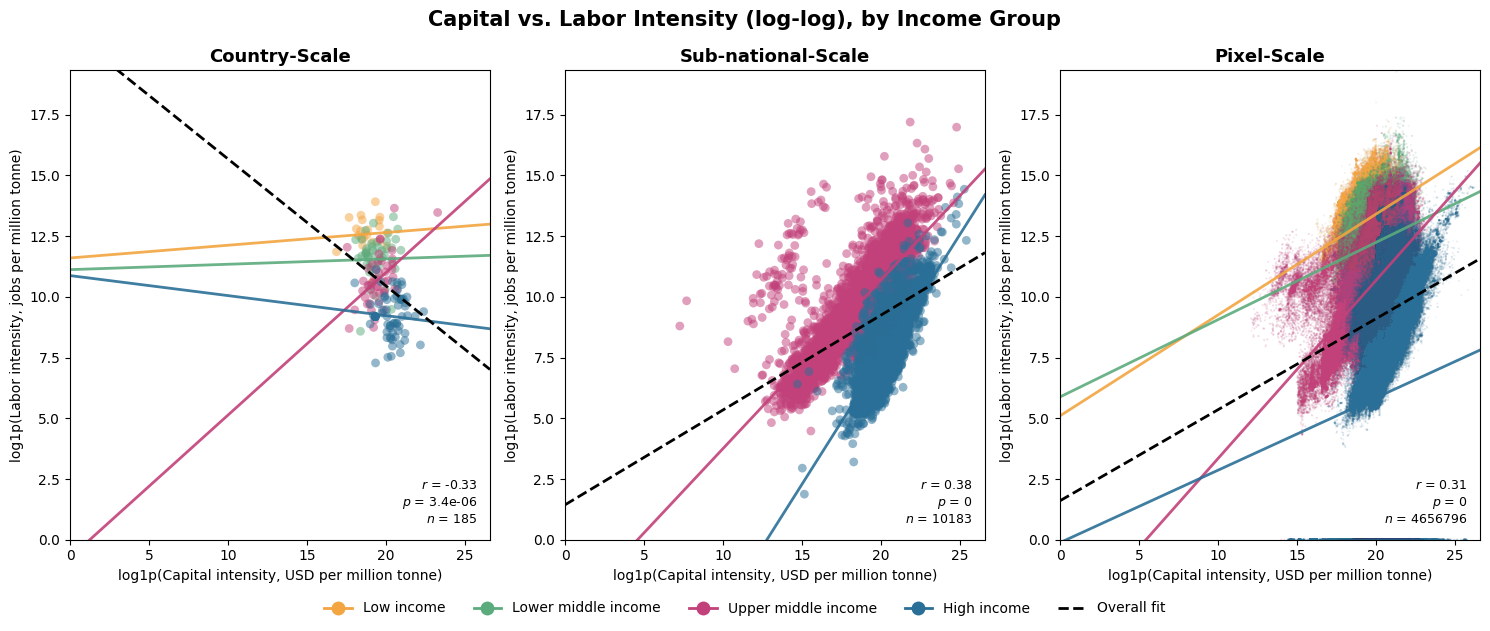

In [18]:
##### Side-by-side scatterplots with line of best fit, colored by income group

### Create color map of income groups
income_colors = {
    "Low income": "#F2A541",          # deep blue
    "Lower middle income": "#5CAB7D", # warm amber
    "Upper middle income": "#C2417A", # muted green
    "High income": "#2A6F97",         # rose/magenta
}

# define plotting function
def plot_scatter(ax, x, y, groups, lr, title, xlabel, ylabel, xlim, ylim,
                  income_colors, point_alpha=0.5, point_size=10, min_group_n=3):
    x_line_full = np.linspace(xlim[0], xlim[1], 100)

    for group, color in income_colors.items():
        mask = groups == group
        n_group = mask.sum()
        if n_group == 0:
            continue

        ax.scatter(
            x[mask], y[mask], alpha=point_alpha, s=point_size,
            color=color, edgecolor="none", label=group
        )

        # income-group-specific line of best fit
        if n_group >= min_group_n:
            lr_group = stats.linregress(x[mask], y[mask])
            y_line_group = lr_group.intercept + lr_group.slope * x_line_full
            ax.plot(x_line_full, y_line_group, color=color, linewidth=2, linestyle="-", alpha=0.9)

    # overall line of best fit 
    y_line = lr.intercept + lr.slope * x_line_full
    ax.plot(x_line_full, y_line, color="black", linewidth=2, linestyle="--", label="Overall fit", zorder=5)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.set_title(title, fontsize=13, weight="bold")
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)

    ax.text(
        0.97, 0.03,
        f"$r$ = {lr.rvalue:.2f}\n$p$ = {lr.pvalue:.2g}\n$n$ = {len(x)}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

# shared axis limits across both panels
x_hi = max(x_country.max(), x_sub.max(), np.percentile(x_pixel, 100))
x_lo = min(x_country.min(), x_sub.min(), np.percentile(x_pixel, 0))
y_hi = max(y_country.max(), y_sub.max(), np.percentile(y_pixel, 100))
y_lo = min(y_country.min(), y_sub.min(), np.percentile(y_pixel, 0))

xlim = (x_lo, x_hi)
ylim = (y_lo, y_hi)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

plot_scatter(
    axes[0], x_country, y_country, income_country, lr_country,
    title="Country-Scale", xlabel="log1p(Capital intensity, USD per million tonne)",
    ylabel="log1p(Labor intensity, jobs per million tonne)",
    xlim=xlim, ylim=ylim, income_colors=income_colors,
    point_size=40
)

plot_scatter(
    axes[1], x_sub, y_sub, income_sub, lr_sub,
    title="Sub-national-Scale", xlabel="log1p(Capital intensity, USD per million tonne)",
    ylabel="log1p(Labor intensity, jobs per million tonne)",
    xlim=xlim, ylim=ylim, income_colors=income_colors,
    point_size=40
)

plot_scatter(
    axes[2], x_pixel, y_pixel, income_pixel, lr_pixel,
    title="Pixel-Scale", xlabel="log1p(Capital intensity, USD per million tonne)",
    ylabel="log1p(Labor intensity, jobs per million tonne)",
    xlim=xlim, ylim=ylim, income_colors=income_colors,
    point_alpha=0.05, point_size=2
)

# --- Build legend manually ---
income_handles = [
    plt.Line2D([0], [0], marker="o", linestyle="-", markersize=10, linewidth=2,
               markerfacecolor=color, markeredgecolor="none", color=color, label=group)
    for group, color in income_colors.items()
]
fit_line_handle = plt.Line2D([0], [0], color="black", linewidth=2, linestyle="--", label="Overall fit")

fig.legend(
    handles=income_handles + [fit_line_handle],
    loc="lower center", ncol=len(income_groups) + 1,
    bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=10
)

fig.suptitle("Capital vs. Labor Intensity (log-log), by Income Group", fontsize=15, weight="bold")
plt.tight_layout()
fig.savefig(f"{fd}/capital_labor_scatter_side_by_side_log_income.png", dpi=300, bbox_inches="tight")
plt.show()

#### Map L/M/H intensity clasifications

In [21]:
##### Classify raster into LMH intensities by terciles 

def classify_lmh(raster, thresholds=(1/3, 2/3)):
    vals = raster.squeeze().values
    valid = np.isfinite(vals)

    low_cut, high_cut = np.nanquantile(vals[valid], thresholds)

    classed = np.full(vals.shape, np.nan)
    classed[valid & (vals <= low_cut)] = 0                      # Low
    classed[valid & (vals > low_cut) & (vals <= high_cut)] = 1  # Medium
    classed[valid & (vals > high_cut)] = 2                       # High

    return classed, (low_cut, high_cut)


capital_class, capital_cuts = classify_lmh(capital_intensity)
labor_class, labor_cuts = classify_lmh(labor_intensity)

print(f"\nCapital tercile cutoffs: {capital_cuts}")
print(f"Labor tercile cutoffs: {labor_cuts}")

# combine into single 0-8 class code: class_id = capital_class * 3 + labor_class
combined_valid = np.isfinite(capital_class) & np.isfinite(labor_class)
class_id = np.full(capital_class.shape, np.nan)
class_id[combined_valid] = capital_class[combined_valid] * 3 + labor_class[combined_valid]

# build classified raster, matching capital_intensity's grid/coords
classified_raster = capital_intensity.squeeze().copy(data=class_id)
classified_raster = classified_raster.rio.write_nodata(np.nan)
classified_raster = classified_raster.rio.write_crs(crs)

classified_raster.rio.to_raster(
    f"{cd}/Results/Raster_model/capital_labor_LMH_classification.tif",
    dtype="float32",
    compress="LZW"
)


Capital tercile cutoffs: (np.float64(381.5716857910156), np.float64(1186.7333984375))
Labor tercile cutoffs: (np.float64(0.010896655730903135), np.float64(0.13743501404921213))


In [22]:
#### Classify country and sub-national data into terciles

# define function to classify L/M/H terciles 
def classify_lmh_from_values(values, thresholds=(1/3, 2/3)):
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values)

    low_cut, high_cut = np.nanquantile(values[valid], thresholds)

    classed = np.full(values.shape, np.nan)
    classed[valid & (values <= low_cut)] = 0
    classed[valid & (values > low_cut) & (values <= high_cut)] = 1
    classed[valid & (values > high_cut)] = 2

    return classed, (low_cut, high_cut)

# classify countries using their own distribution's terciles 
country_boundaries['capital_class'], country_capital_cuts = classify_lmh_from_values(
    country_boundaries['capital_intensity_USD_per_tonne']
)
country_boundaries['labor_class'], country_labor_cuts = classify_lmh_from_values(
    country_boundaries['labor_intensity_jobs_per_tonne']
)

print(f"Country capital tercile cutoffs: {country_capital_cuts}")
print(f"Country labor tercile cutoffs: {country_labor_cuts}")


# classify sub-national using their own distribution's terciles 
sub_national['capital_class'], sub_capital_cuts = classify_lmh_from_values(
    sub_national['capital_intensity_USD_per_tonne']
)
sub_national['labor_class'], sub_labor_cuts = classify_lmh_from_values(
    sub_national['labor_intensity_jobs_per_tonne']
)

print(f"Sub-national capital tercile cutoffs: {sub_capital_cuts}")
print(f"Sub-national labor tercile cutoffs: {sub_labor_cuts}")

Country capital tercile cutoffs: (np.float64(248.57472954686676), np.float64(566.8135718928794))
Country labor tercile cutoffs: (np.float64(0.0199004152960961), np.float64(0.1057562296744452))
Sub-national capital tercile cutoffs: (np.float64(202.59560767504257), np.float64(723.8452032884129))
Sub-national labor tercile cutoffs: (np.float64(0.003240717425852666), np.float64(0.022126136866866458))


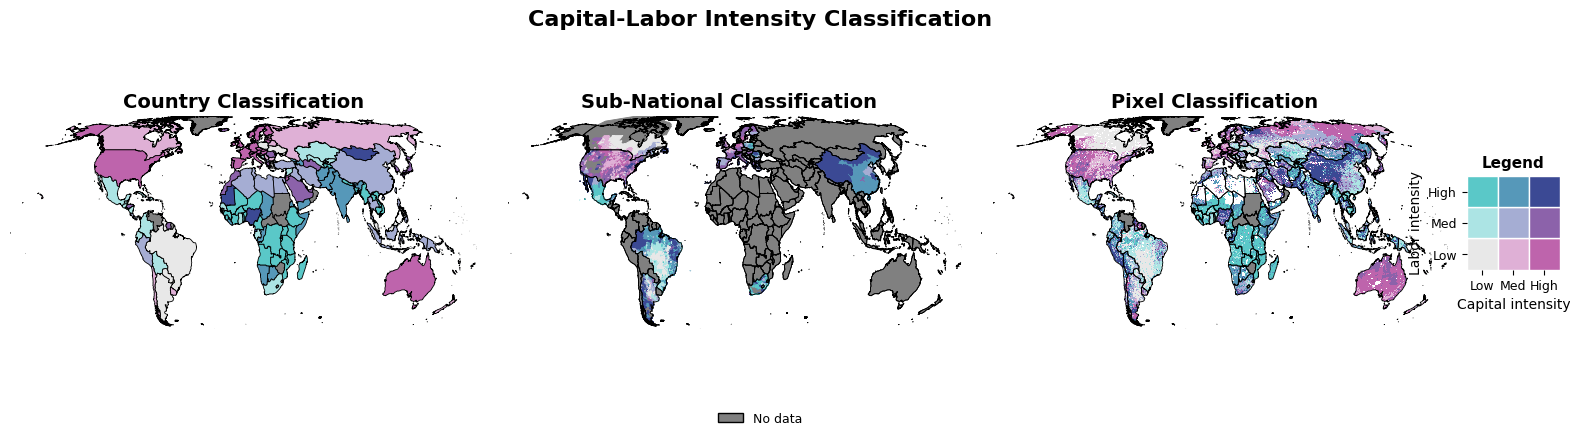

In [23]:
##### Plot classified raster with country choropleth and 3x3 grid legend

# filter valid country/sub-national data 
country_combined_valid = country_boundaries['capital_class'].notna() & country_boundaries['labor_class'].notna()
country_boundaries['class_id'] = np.nan
country_boundaries.loc[country_combined_valid, 'class_id'] = (
    country_boundaries.loc[country_combined_valid, 'capital_class'] * 3
    + country_boundaries.loc[country_combined_valid, 'labor_class']
)

sub_combined_valid = sub_national['capital_class'].notna() & sub_national['labor_class'].notna()
sub_national['class_id'] = np.nan
sub_national.loc[sub_combined_valid, 'class_id'] = (
    sub_national.loc[sub_combined_valid, 'capital_class'] * 3
    + sub_national.loc[sub_combined_valid, 'labor_class']
)

# bivariate color scheme: rows = labor class (0=L,1=M,2=H), cols = capital class (0=L,1=M,2=H)
# shared across both panels — same colors mean same L/M/H class in each panel's own distribution
bivariate_colors = {
    (0, 0): '#e8e8e8', (1, 0): '#ace4e4', (2, 0): '#5ac8c8',   # capital = Low
    (0, 1): '#dfb0d6', (1, 1): '#a5add3', (2, 1): '#5698b9',   # capital = Medium
    (0, 2): '#be64ac', (1, 2): '#8c62aa', (2, 2): '#3b4994',   # capital = High
}

# key = (labor_class, capital_class)
cmap_list = [bivariate_colors[(lab, cap)] for cap in range(3) for lab in range(3)]

# ordered to match class_id = capital_class * 3 + labor_class
bivariate_cmap = plt.matplotlib.colors.ListedColormap(cmap_list)
bounds = np.arange(-0.5, 9.5, 1)
norm = plt.matplotlib.colors.BoundaryNorm(bounds, bivariate_cmap.N)

missing_color = "grey"

# --- Compute figure height from actual data aspect ratio to remove excess whitespace ---
minx, miny, maxx, maxy = country_boundaries.total_bounds
data_width = maxx - minx
data_height = maxy - miny
data_aspect = data_height / data_width  # height/width ratio of the map content

fig_width = 20
# 3 map panels share width_ratios [5, 5, 5, 1] -> each map panel is 5/16 of total width
panel_width = fig_width * (5 / 16)
fig_height = panel_width * data_aspect + 1.5  # +1.5 in. for suptitle/panel titles/bottom legend

fig = plt.figure(figsize=(fig_width, fig_height))
gs = fig.add_gridspec(1, 4, width_ratios=[5, 5, 5, 1], wspace=0.05)

# --- Left panel: country choropleth (own-distribution terciles) ---
ax_country = fig.add_subplot(gs[0])

country_has_data = country_boundaries[country_boundaries['has_capital_and_labor_data'] == 1]
country_no_data = country_boundaries[country_boundaries['has_capital_and_labor_data'] == 0]

country_no_data.plot(ax=ax_country, facecolor=missing_color, edgecolor="black", linewidth=0.6, zorder=1)
country_has_data.plot(
    ax=ax_country, column="class_id", cmap=bivariate_cmap, norm=norm,
    edgecolor="black", linewidth=0.6, zorder=2
)

ax_country.set_xlim(minx, maxx)
ax_country.set_ylim(miny, maxy)
ax_country.set_axis_off()
ax_country.set_title("Country Classification", fontsize=14, weight="bold")

# --- Middle panel: country choropleth (own-distribution terciles) ---
ax_sub = fig.add_subplot(gs[1])

sub_has_data = sub_national[sub_national['class_id'].notna()]
sub_no_data = sub_national[sub_national['class_id'].isna()]

country_boundaries.plot(ax=ax_sub, facecolor=missing_color, edgecolor="black", linewidth=0.6, zorder=1)

sub_no_data.plot(ax=ax_sub, facecolor=missing_color, edgecolor=missing_color, linewidth=0.6, zorder=1)

colors = [to_hex(bivariate_cmap(norm(v))) for v in sub_has_data["class_id"]]

sub_has_data.plot(
    ax=ax_sub,
    color=colors,
    edgecolor=colors,
    linewidth=0.6,
    zorder=2,
)

country_boundaries.plot(ax=ax_sub, facecolor="none", edgecolor="black", linewidth=0.6, zorder=3)

ax_sub.set_xlim(minx, maxx)
ax_sub.set_ylim(miny, maxy)
ax_sub.set_axis_off()
ax_sub.set_title("Sub-National Classification", fontsize=14, weight="bold")

# --- Right panel: pixel raster classification (own-distribution terciles) ---
ax_map = fig.add_subplot(gs[2])

country_boundaries[country_boundaries['has_capital_and_labor_data'] == 0].plot(
    ax=ax_map, facecolor=missing_color, edgecolor="black", linewidth=0.6, zorder=1
)

classified_raster.plot(
    ax=ax_map, cmap=bivariate_cmap, norm=norm,
    add_colorbar=False, add_labels=False, zorder=2
)

country_boundaries.plot(ax=ax_map, facecolor="none", edgecolor="black", linewidth=0.6, zorder=3)

ax_map.set_xlim(minx, maxx)
ax_map.set_ylim(miny, maxy)
ax_map.set_axis_off()
ax_map.set_title("Pixel Classification", fontsize=14, weight="bold")

fig.suptitle("Capital-Labor Intensity Classification", fontsize=16, weight="bold", y=0.98)

# --- 3x3 grid legend panel (shared) ---
ax_legend = fig.add_subplot(gs[3])
ax_legend.set_aspect("equal")

labels_lmh = ["Low", "Med", "High"]

for cap in range(3):       # x-axis: capital class
    for lab in range(3):   # y-axis: labor class
        ax_legend.add_patch(
            mpatches.Rectangle((cap, lab), 1, 1, facecolor=bivariate_colors[(lab, cap)], edgecolor="white")
        )

ax_legend.set_xlim(0, 3)
ax_legend.set_ylim(0, 3)
ax_legend.set_xticks([0.5, 1.5, 2.5])
ax_legend.set_xticklabels(labels_lmh, fontsize=9)
ax_legend.set_yticks([0.5, 1.5, 2.5])
ax_legend.set_yticklabels(labels_lmh, fontsize=9)
ax_legend.set_xlabel("Capital intensity", fontsize=10)
ax_legend.set_ylabel("Labor intensity", fontsize=10)
ax_legend.set_title("Legend", fontsize=11, weight="bold")
for spine in ax_legend.spines.values():
    spine.set_visible(False)

missing_patch = mpatches.Patch(facecolor=missing_color, edgecolor="black", label="No data")
fig.legend(handles=[missing_patch], loc="lower center", bbox_to_anchor=(0.5, 0.0), frameon=False, fontsize=9)

fig.subplots_adjust(top=0.90, bottom=0.08, wspace=0.05)
fig.savefig(f"{fd}/capital_labor_LMH_classification_map.png", dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.show()